<a href="https://colab.research.google.com/github/riyakhan146khan85/SpaceX_Operations_AI/blob/main/Project_1_SpaceX_Operations_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('Project_1_SpaceX_Operations_AI.ipynb')

Project_1_SpaceX_Operations_AI.ipynb


In [ ]:
import pandas as pd
import numpy as np
data_url = 'https://githubusercontent.com'
try:
    spacex_df = pd.read_csv(data_url)
    print('SpaceX data loaded successfully')
    print(f'Total historical space mission tracked: {len(spacex_df)}')
except Exception as error:
    print(f'Connection failed: {error}. Trying alternate database...')
    backup_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv'
    spacex_df = pd.read_csv(backup_url)
    print(f'Corrected Dimensions: {spacex_df.shape}')
    print('\n---Available Columns in our SpaceX Dataset---')
    print(spacex_df.columns.tolist())
    print('---Missing Values Per Column---')
    print(spacex_df.isnull().sum())
    print('\n---Unique Mission Outcome---')
    print(spacex_df['Outcome'].unique())

Connection failed: <urlopen error [Errno -5] No address associated with hostname>. Trying alternate database...
Corrected Dimensions: (90, 17)

---Available Columns in our SpaceX Dataset---
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude']
---Missing Values Per Column---
FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

---Unique Mission Outcome---
['None None' 'False Ocean' 'True Ocean' 'False ASDS' 'None ASDS'
 'True RTLS' 'True ASDS' 'False RTLS']


In [ ]:
spacex_df['LandingPad'] = spacex_df['LandingPad'].fillna('None')
print('---Missing Values After Cleaning---')
print(spacex_df['LandingPad'].isnull().sum())

---Missing Values After Cleaning---
0


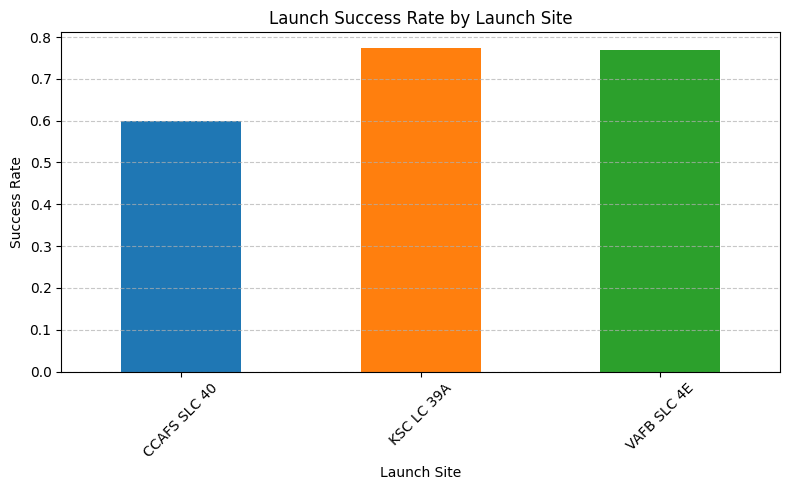

In [ ]:
import matplotlib.pyplot as plt
spacex_df['Is_Success'] = spacex_df['Outcome'].str.startswith('True').astype(int)
site_success = spacex_df.groupby('LaunchSite')['Is_Success'].mean()
plt.figure(figsize=(8, 5))
site_success.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Launch Success Rate by Launch Site')
plt.xlabel('Launch Site')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Code to define spacex_df (using the backup URL directly as the primary URL failed previously)
backup_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv'
spacex_df = pd.read_csv(backup_url)

# Code to clean LandingPad column
spacex_df['LandingPad'] = spacex_df['LandingPad'].fillna('None')

# Code to create Is_Success column
spacex_df['Is_Success'] = spacex_df['Outcome'].str.startswith('True').astype(int)

# Original modeling code
features = spacex_df[['PayloadMass', 'Orbit', 'LaunchSite', 'LandingPad']]
target = spacex_df['Is_Success']
x = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad'], dtype=int)
y = target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(x_train, y_train)
y_pred = random_forest.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
# Corrected typo in variable name and renamed to avoid conflict with function name
classification_report_output = classification_report(y_test, y_pred)
print(f'Spacex Operations AI Accuracy:[{accuracy * 100:.2f}]%')
# Corrected invalid escape sequence from 'n\' to '\n'
print('\n---Model Performance Report---')
print(classification_report_output)


Spacex Operations AI Accuracy:[83.33]%

---Model Performance Report---
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.92      0.86      0.89        14

    accuracy                           0.83        18
   macro avg       0.76      0.80      0.78        18
weighted avg       0.85      0.83      0.84        18



In [ ]:
import pandas as pd
new_launch = pd.DataFrame([{'PayloadMass': 6000.0,
                            'Orbit': 'GTO',
                            'LaunchSite': 'KSC LC 39A',
                            'LaunchingPad':'5e9e3025d924605853b237d'}])
new_launch_encoded = pd.get_dummies(new_launch, columns=['Orbit', 'LaunchSite', 'LaunchingPad'], dtype=int)
new_launch_encoded = new_launch_encoded.reindex(columns=x.columns, fill_value=0)
live_prediction = random_forest.predict(new_launch_encoded)
probability = random_forest.predict_proba(new_launch_encoded)
failure_prob = probability[0][0] * 100
success_prob_prob = probability[0][1] * 100
print('---xAI Operations Assistant Flight Decision')
if live_prediction == 1:
  print(f'PREDICTON: SUCCESSFUL BOOSTER LANDING RECOVERY!')
  print(f'AI Confidence Score:{success_prob:.2f}% Success Probability')
else:
  print(f'PREDICTION: UNSUCCESSFUL BOOSTER LANDING RECOVERY!')
  print(f'AI Risk Probability:{failure_prob:.2f}% Crash Probability')


---xAI Operations Assistant Flight Decision
PREDICTON: SUCCESSFUL BOOSTER LANDING RECOVERY!
AI Confidence Score:54.00% Success Probability
